In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("Social_Network_Ads.csv")

In [5]:
import matplotlib.pyplot as plt
import seaborn as s

In [6]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
x = df.iloc[:, [2, 3]].values

In [8]:
y = df.iloc[:, 4].values

In [9]:
import sklearn

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
sc = StandardScaler()

In [14]:
X_train = sc.fit_transform(X_train)

In [15]:
X_test = sc.fit_transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
classifier = LogisticRegression()

In [18]:
classifier.fit(X_train, y_train)

LogisticRegression()

In [19]:
y_pred = classifier.predict(X_test)

In [20]:
result = pd.DataFrame({'Actual': y_test, 'predicted': y_pred})

In [21]:
result

,Actual,predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
95,0,0
96,1,1
97,0,0
98,1,1


In [22]:
result.head(15)

,Actual,predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


In [23]:
from sklearn.metrics import precision_score, confusion_matrix, accuracy_score, recall_score
cm = confusion_matrix(y_test, y_pred)

In [24]:
cm

array([[61,  2],
       [12, 25]])

In [25]:
TN = cm[0][0]
print("TN:", TN)

TN: 61


In [26]:
FP = cm[0][1]
print("FP:", FP)

FP: 2


In [27]:
FN = cm[1][0]
print("FN:", FN)

FN: 12


In [28]:
TP = cm[1][1]
print("TP:", TP)

TP: 25


In [29]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", accuracy)

Accuracy: 0.86


In [30]:
error_rate = (FP + FN) / (TP + TN + FP + FN)
print("error rate", error_rate)

error rate 0.14


In [31]:
precision = TP / (TP + FP)
print("Precision:", precision)

Precision: 0.9259259259259259


In [32]:
recall = TP / (TP + FN)
print("Recall:", recall)

Recall: 0.6756756756756757


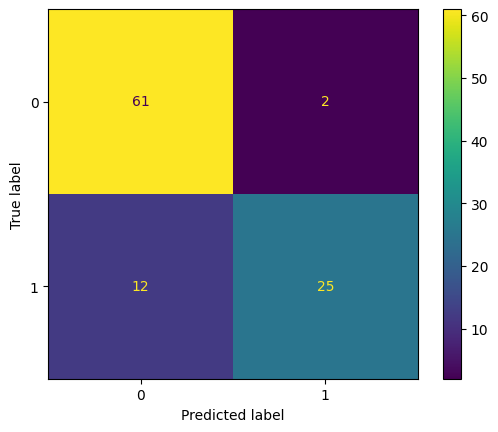

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()